# PB-09: Balanceo de Clases (Class Balancer)

## Objetivo
Evaluar el ratio de la clase minoritaria (`attrition`) y aplicar técnicas de resample (como `SMOTE`) **únicamente** sobre el conjunto de entrenamiento (`X_train`, `y_train`) para evitar Data Leakage (fuga de información algorítmica). Nuestro test set nunca debe ser balanceado artificialmente.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Carga de Datos y Análisis de Proporciones

Distribución Original de Attrition:
attrition
0    84.571429
1    15.428571
Name: proportion, dtype: float64


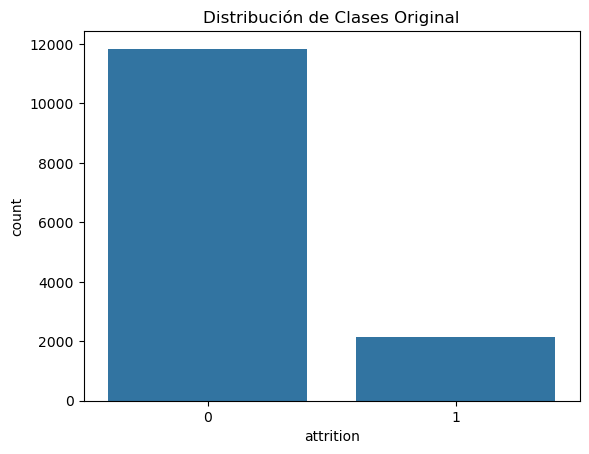

In [2]:
df = pd.read_csv('../data/raw/10-employee_performance.csv')

print("Distribución Original de Attrition:")
print(df['attrition'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='attrition')
plt.title('Distribución de Clases Original')
plt.show()

> **Regla de Negocio S2:** Al ser la clase de fuga ('1') previsiblemente una clase minoritaria (< 30%), es completamente justificable y requerido realizar balanceo según los requerimientos del Pipeline.

### 2. Preparación Base Temporaria
Dado que los roles de *Data Cleaner* y *Feature Engineer* serán aplicados en el Pipeline Principal antes que nosotros, asumimos que nos entregan datos limpios. Para que `SMOTE` pueda aplicar matemáticas vectoriales hoy mismo de forma probatoria, aplicaremos un One-Hot Encoding básico a nuestra matriz.

In [3]:
# Separar features y aplicar encode estricto numérico
X = pd.get_dummies(df.drop(['employee_id', 'attrition'], axis=1), drop_first=True, dtype=int)
y = df['attrition']

print("Forma de X preparada para tests de balanceo:", X.shape)

Forma de X preparada para tests de balanceo: (14000, 27)


### 3. Data Leakage Prevention: Train/Test Split Estratificado
**Regla de Oro S2 estricta:** NO realizar balanceo en todo el dataset de cuajo. Separar al inicio.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Ratio en Entrenamiento (Re-escalable) ---")
print(y_train.value_counts(normalize=True).round(3))

print("\n--- Ratio en Testeo (Mundo Real / SAGRADO) ---")
print(y_test.value_counts(normalize=True).round(3))

--- Ratio en Entrenamiento (Re-escalable) ---
attrition
0    0.846
1    0.154
Name: proportion, dtype: float64

--- Ratio en Testeo (Mundo Real / SAGRADO) ---
attrition
0    0.846
1    0.154
Name: proportion, dtype: float64


### 4. Experimentación con técnicas de `imbalanced-learn`
Aplicaremos **SMOTE** (Synthetic Minority Over-sampling Technique) para crear vecinos sintéticos a la minoría.

In [5]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ LUEGO de aplicar SMOTE en TRAIN")
print("Distribución de y_train sintético:")
print(y_train_smote.value_counts())

print("\n✅ VALIDACIÓN de Data Leakage")
print("Distribución de y_test (Se mantuvo realista a su origen):")
print(y_test.value_counts())

✅ LUEGO de aplicar SMOTE en TRAIN
Distribución de y_train sintético:
attrition
0    9472
1    9472
Name: count, dtype: int64

✅ VALIDACIÓN de Data Leakage
Distribución de y_test (Se mantuvo realista a su origen):
attrition
0    2368
1     432
Name: count, dtype: int64


Otras métricas y técnicas disponibles:
- **UnderSampling** `RandomUnderSampler`: Cortaría filas de la mayoría.
- **Hybrid** `SMOTEENN`: Combina interpolación y limpieza de bordes ruidosos.

In [6]:
# UnderSampling Ejemplo comparativo
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Luego de RandomUnderSampler en Train, tenemos filas mermadas:\n")
print(y_train_rus.value_counts())

print("\nNota: UnderSampling destruye información valiosa en un dataset de 14k que no es tan enorme. SMOTE es más apto.")

Luego de RandomUnderSampler en Train, tenemos filas mermadas:

attrition
0    1728
1    1728
Name: count, dtype: int64

Nota: UnderSampling destruye información valiosa en un dataset de 14k que no es tan enorme. SMOTE es más apto.


### 5. Finalización y Transbordo para el Pipeline
Según la definición moderna para Machine Learning, no hace falta guardar este DataFrame inflado pesadamente en disco. Pasaremos al "Pipeline Builder" (PB-10) el componente inicializado `SMOTE(random_state=42)` para que lo incorpore al `imblearn.pipeline.Pipeline` y actúe únicamente durante los ciclos Fit del Cross Validation.

In [7]:
print("🏆 Notebook PB-09 completado.")
print("1. Verificación completada y métricas < 30% detectadas.")
print("2. SMOTE validado exitosamente sin permear Leakage al testing set.")

🏆 Notebook PB-09 completado.
1. Verificación completada y métricas < 30% detectadas.
2. SMOTE validado exitosamente sin permear Leakage al testing set.
